In [21]:
#%pip install lightgbm xgboost catboost


In [22]:
import torch


print('✅ PyTorch GPU dispo:', torch.cuda.is_available())

✅ PyTorch GPU dispo: True


In [23]:
import os
import pandas as pd
import joblib
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from src.simulator_betting import *
from src.simulator_grid import *
from src.config import *
from src.utils import get_latest_file

import json

pd.set_option("display.max_columns", None)

from src.simulator_grid import run_parallel_simulations

In [ ]:
bets_df, summary = run_season_simulation(
            seasons_to_test=["2018-19","2019-20","2020-21","2021-22","2022-23","2023-24","2024-25"],
            exclude_future_seasons=True,
            min_ev=0.01,
            odds_max=2.2,
            odds_min=1.2,
            prob_diff=0.00001,
            ev_diff_min=0.00001,
            prob_diff_vs_book_range=(0.0755, 1.0),
            bankroll=1000,
            max_risk=0.3,
            stake_method="kelly",
            streak_limit=3,
            bankroll_stop=0,
            skip_first_n=0,
            model_identifier="odds_venv",
            reset_bankroll_each_season=True,
            parallel = True
        )


#save the bets DataFrame to a CSV file

os.makedirs(DATA_SIMULATIONS_DIR, exist_ok=True)
today = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
bets_output_file = os.path.join(DATA_SIMULATIONS_DIR, f"bets_{today}.csv")

bets_df.to_csv(bets_output_file, index=False)



--- Saison: 2018-19 ---
Model in parallel mode: True. n_jobs set to -1
ROC AUC sur validation: 0.7476
Modèle sauvegardé dans data\models\simulations\model_2018-19_odds_venv.joblib
dataset cols before SIM : ['GAME_ID', 'TEAM_ID', 'GAME_DATE', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TO', 'PF', 'PTS', 'PLUS_MINUS', 'MINUTES_PLAYED', 'OPP_TEAM_ID', 'OPP_GAME_DATE', 'OPP_FGM', 'OPP_FGA', 'OPP_FG_PCT', 'OPP_FG3M', 'OPP_FG3A', 'OPP_FG3_PCT', 'OPP_FTM', 'OPP_FTA', 'OPP_FT_PCT', 'OPP_OREB', 'OPP_DREB', 'OPP_REB', 'OPP_AST', 'OPP_STL', 'OPP_BLK', 'OPP_TO', 'OPP_PF', 'OPP_PTS', 'OPP_PLUS_MINUS', 'OPP_MINUTES_PLAYED', 'MATCHUP', 'SEASON', 'IS_HOME', 'IS_WIN', 'POINT_DIFF', 'TEAM_NAME', 'OPPONENT_NAME', 'ODDS', 'OPP_ODDS', 'TS_PCT', 'EFG_PCT', 'AST_TO_RATIO', 'REB_RATE', 'POSSESSIONS', 'OPP_POSSESSIONS', 'OFF_RATING', 'DEF_RATING', 'ROLL_PTS_3', 'ROLL_PTS_5', 'ROLL_PTS_10', 'ROLL_PTS_25', 'ROLL_PTS_50', 'ROLL_PTS_100',

In [ ]:
print("Summary of bets :")
print(summary)

Summary of bets :
{'total_analysed': 5209, 'total_bet_placed': 68, 'wins': np.int64(41), 'roi': np.float64(0.12560824022784897), 'final_bankroll': np.float64(2289.960419756051)}


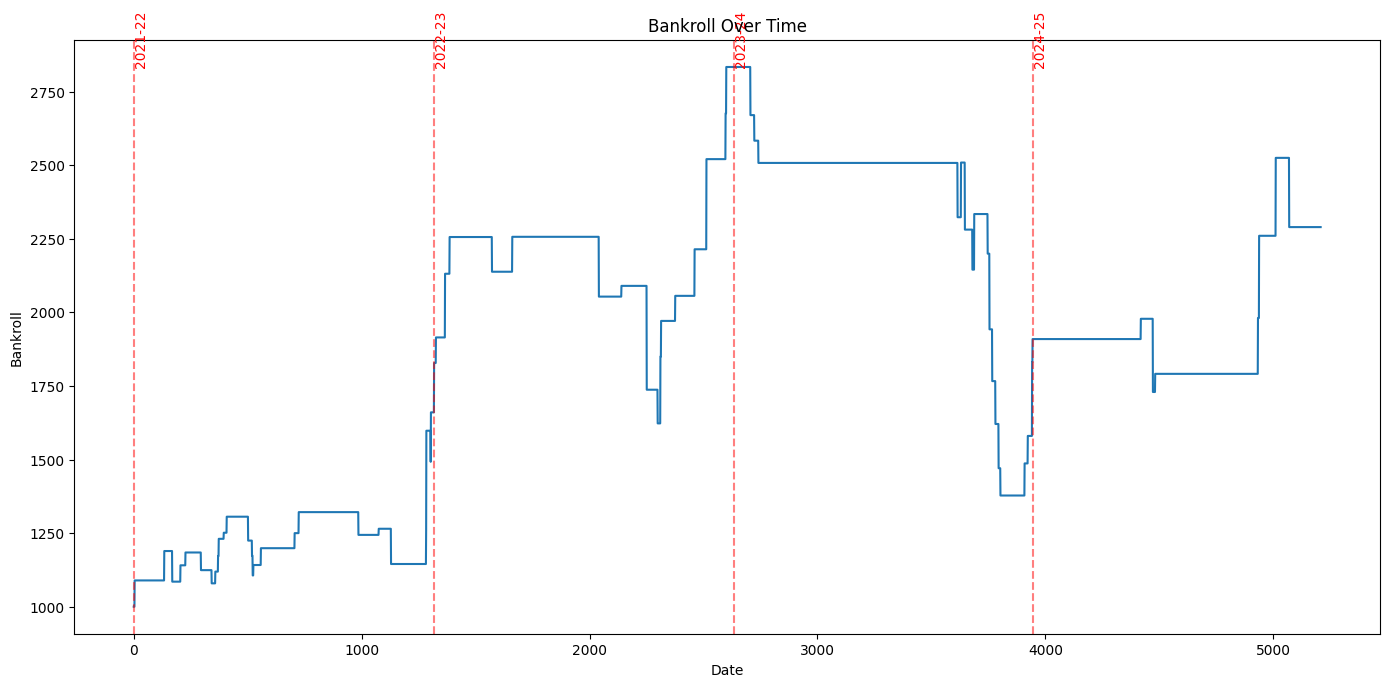

In [ ]:

plot_bankroll(bets_df)



In [ ]:
# results = run_parallel_simulations(
#     seasons=["2022-23"], #, "2023-24"],
#     model_identifier="grid_odds",
#     reset_bankroll_each_season=False
# )


In [ ]:

import pandas as pd
from src.utils import get_latest_file
from src.config import DATA_SIMULATIONS_DIR
from src.simulator_betting import analyze_bets_diagnostics,analyze_performance_by_odds


# Affiche toutes les lignes
pd.set_option("display.max_rows", None)
# Affiche toutes les colonnes (si besoin)
pd.set_option("display.max_columns", None)

#latest simulation file
latest_simulation_file = get_latest_file(DATA_SIMULATIONS_DIR)
print(f"Latest simulation file: {latest_simulation_file}")


#analyse edge bookmaker/models on the latest simulation file
latest_bets_df = pd.read_csv(latest_simulation_file)
diagnostics = analyze_bets_diagnostics(latest_bets_df)

#cut 50 first and last 50 rows of diagnostics
diagnostics = diagnostics.iloc[70:-60]
print("Diagnostics of bets:")
diagnostics


Latest simulation file: data\simulations\bets_2025-06-02_21-07-52.csv
Diagnostics of bets:


e:\Documents_\Dev\NBA_Predictor\src\simulator_betting.py:390: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diagnostics = df.groupby("diff_bin").agg(


,diff_bin,count,win_rate,avg_gain,total_gain,avg_prob_diff_vs_book
70,"(-0.125, -0.113]",0,NaN,NaN,0.000000,NaN
71,"(-0.113, -0.1]",0,NaN,NaN,0.000000,NaN
72,"(-0.1, -0.0875]",0,NaN,NaN,0.000000,NaN
73,"(-0.0875, -0.075]",0,NaN,NaN,0.000000,NaN
74,"(-0.075, -0.0625]",0,NaN,NaN,0.000000,NaN
75,"(-0.0625, -0.05]",0,NaN,NaN,0.000000,NaN
76,"(-0.05, -0.0375]",0,NaN,NaN,0.000000,NaN
77,"(-0.0375, -0.025]",0,NaN,NaN,0.000000,NaN
78,"(-0.025, -0.0125]",0,NaN,NaN,0.000000,NaN
79,"(-0.0125, -3.55e-15]",0,NaN,NaN,0.000000,NaN


In [ ]:
analyze_performance_by_odds(latest_bets_df)

e:\Documents_\Dev\NBA_Predictor\src\simulator_betting.py:409: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = df.groupby("odds_bin").agg(


,odds_bin,count,win_rate,avg_gain,total_gain,avg_stake
0,"(1.0, 1.1]",0,NaN,NaN,0.000000,NaN
1,"(1.1, 1.2]",0,NaN,NaN,0.000000,NaN
2,"(1.2, 1.3]",0,NaN,NaN,0.000000,NaN
3,"(1.3, 1.4]",1,1.000000,36.503961,36.503961,110.618063
4,"(1.4, 1.5]",4,1.000000,55.925304,223.701216,115.190082
5,"(1.5, 1.6]",8,0.500000,-58.154651,-465.237204,126.818094
6,"(1.6, 1.7]",18,0.666667,31.751488,571.526776,149.901956
7,"(1.7, 1.8]",13,0.692308,45.447181,590.813359,134.741119
8,"(1.8, 1.9]",3,0.333333,-102.652522,-307.957565,162.951465
9,"(1.9, 2.0]",5,0.400000,18.263347,91.316734,211.261625


In [ ]:
#analyse la saison 2023-24

season_2023_24_bets = latest_bets_df[latest_bets_df["season"] == "2023-24"]
print("Season 2023-24 bets diagnostics:")
season_2023_24_diagnostics = analyze_bets_diagnostics(season_2023_24_bets)
season_2023_24_diagnostics = season_2023_24_diagnostics.iloc[70:-60]

display(season_2023_24_diagnostics)

season_2023_24_perfs_odds = analyze_performance_by_odds(season_2023_24_bets)
print("Performance by odds for season 2023-24:")
display(season_2023_24_perfs_odds)

Season 2023-24 bets diagnostics:


e:\Documents_\Dev\NBA_Predictor\src\simulator_betting.py:390: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  diagnostics = df.groupby("diff_bin").agg(


,diff_bin,count,win_rate,avg_gain,total_gain,avg_prob_diff_vs_book
70,"(-0.125, -0.113]",0,NaN,NaN,0.000000,NaN
71,"(-0.113, -0.1]",0,NaN,NaN,0.000000,NaN
72,"(-0.1, -0.0875]",0,NaN,NaN,0.000000,NaN
73,"(-0.0875, -0.075]",0,NaN,NaN,0.000000,NaN
74,"(-0.075, -0.0625]",0,NaN,NaN,0.000000,NaN
75,"(-0.0625, -0.05]",0,NaN,NaN,0.000000,NaN
76,"(-0.05, -0.0375]",0,NaN,NaN,0.000000,NaN
77,"(-0.0375, -0.025]",0,NaN,NaN,0.000000,NaN
78,"(-0.025, -0.0125]",0,NaN,NaN,0.000000,NaN
79,"(-0.0125, -3.55e-15]",0,NaN,NaN,0.000000,NaN


Performance by odds for season 2023-24:


e:\Documents_\Dev\NBA_Predictor\src\simulator_betting.py:409: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis = df.groupby("odds_bin").agg(


,odds_bin,count,win_rate,avg_gain,total_gain,avg_stake
0,"(1.0, 1.1]",0,NaN,NaN,0.000000,NaN
1,"(1.1, 1.2]",0,NaN,NaN,0.000000,NaN
2,"(1.2, 1.3]",0,NaN,NaN,0.000000,NaN
3,"(1.3, 1.4]",0,NaN,NaN,0.000000,NaN
4,"(1.4, 1.5]",0,NaN,NaN,0.000000,NaN
5,"(1.5, 1.6]",1,0.000000,-86.849568,-86.849568,86.849568
6,"(1.6, 1.7]",4,0.250000,-90.088522,-360.354086,146.799967
7,"(1.7, 1.8]",4,0.500000,-17.124387,-68.497547,125.160548
8,"(1.8, 1.9]",2,0.000000,-196.570893,-393.141786,196.570893
9,"(1.9, 2.0]",1,0.000000,-184.514158,-184.514158,184.514158
